In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

# GoogleNet, Inception-v1

In [2]:
%%capture
!pip -q install lightning torchinfo

### Module import

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## Model Define

> **코드 일부 수정**  
> LRN -> BN  
  Aux clasifier 생략   
  test를 위해 Class 1000 -> 5

In [4]:
class Wrap_5(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=5)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=5)
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

* Conv2d(in_c, out_c, kernel_size, stride, padding)


In [5]:
## Conv2d(in_c, out_c, kernel_size, stride, padding)

def conv_1(in_dim,out_dim):
    module = nn.Sequential(
        nn.Conv2d(in_dim,out_dim,1,1), #(in,out,kernel_size,stride)
        nn.ReLU())
    return module

def conv_1_3(in_dim,mid_dim,out_dim):
    module = nn.Sequential(
        nn.Conv2d(in_dim,mid_dim,1,1),
        nn.ReLU(),
        nn.Conv2d(mid_dim,out_dim,3,1,1),
        nn.ReLU())
    return module

def conv_1_5(in_dim,mid_dim,out_dim):
    module = nn.Sequential(
        nn.Conv2d(in_dim,mid_dim,1,1),
        nn.ReLU(),
        nn.Conv2d(mid_dim,out_dim,5,1,2),
        nn.ReLU())
    return module

def max_3_1(in_dim,out_dim):
    module = nn.Sequential(
        nn.MaxPool2d(kernel_size=3,stride=1,padding=1),
        nn.Conv2d(in_dim,out_dim,1,1),
        nn.ReLU())
    return module

In [6]:
# Inception 모듈 정의
class inception_module(nn.Module):
    def __init__(self,in_dim,out_dim_1,mid_dim_3,out_dim_3,mid_dim_5,out_dim_5,pool_dim):
        super(inception_module,self).__init__()
        # 1x1 Convolution
        self.conv_1 = conv_1(in_dim,out_dim_1)
        # 1x1 Convolution -> 3x3 Convolution
        self.conv_1_3 = conv_1_3(in_dim,mid_dim_3,out_dim_3)
        # 1x1 Convolution -> 5x5 Convolution
        self.conv_1_5 = conv_1_5(in_dim,mid_dim_5,out_dim_5)
        # 3x3 MaxPooling -> 1x1 Convolution
        self.max_3_1 = max_3_1(in_dim,pool_dim)

    def forward(self,x):
        out_1 = self.conv_1(x)
        out_2 = self.conv_1_3(x)
        out_3 = self.conv_1_5(x)
        out_4 = self.max_3_1(x)
        # concat
        output = torch.cat([out_1,out_2,out_3,out_4],1)#(bs,c,h,w)
        return output

In [7]:
# Conv2d(in_c, out_c, kernel_size, stride, padding)

#from IPython.core.display import ProgressBar

batch_size = 16

class GoogLeNet(Wrap_5):
    def __init__(self, base_dim=64, num_classes=1000):
        super(GoogLeNet, self).__init__()
        self.num_classes=num_classes
        self.layer_1 = nn.Sequential(
            nn.Conv2d(3,base_dim,7,2,3),
            nn.BatchNorm2d(base_dim),
            nn.ReLU(),
            nn.MaxPool2d(3,2,1),
            nn.Conv2d(base_dim,base_dim*3,3,1,1),
            nn.BatchNorm2d(base_dim*3),
            nn.ReLU(),
            nn.MaxPool2d(3,2,1),
        )
        self.layer_2 = nn.Sequential(
            inception_module(base_dim*3,64,96,128,16,32,32),  #256=64+128+32+32
            inception_module(base_dim*4,128,128,192,32,96,64),#480
            nn.MaxPool2d(3,2,1),
        )
        self.layer_3 = nn.Sequential(
            inception_module(480,192,96,208,16,48,64),        #512
            inception_module(512,160,112,224,24,64,64),       #512
            inception_module(512,128,128,256,24,64,64),       #512
            inception_module(512,112,144,288,32,64,64),       #528
            inception_module(528,256,160,320,32,128,128),     #832
            nn.MaxPool2d(3,2,1),
        )
        self.layer_4 = nn.Sequential(
            inception_module(832,256,160,320,32,128,128),     #832
            inception_module(832,384,192,384,48,128,128),     #1024
            nn.AvgPool2d(7,1),
        )
        self.layer_5 = nn.Dropout2d(0.4)
        self.fc_layer = nn.Linear(1024,self.num_classes)

    def forward(self, x):
        out = self.layer_1(x)
        out = self.layer_2(out)
        out = self.layer_3(out)
        out = self.layer_4(out)  #(bs,1024,1,1)
        out = self.layer_5(out)
        out = out.view(-1, 1024) #(bs,1024)
        out = self.fc_layer(out) #(bs,classes)
        return out

In [8]:
img_shape = (224, 224, 3)
model = GoogLeNet()
#model = GoogLeNet(num_classes=5)
summary(model, input_size=(16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [16, 1000]                --
├─Sequential: 1-1                        [16, 192, 28, 28]         --
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        9,472
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        128
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [16, 64, 56, 56]          --
│    └─Conv2d: 2-5                       [16, 192, 56, 56]         110,784
│    └─BatchNorm2d: 2-6                  [16, 192, 56, 56]         384
│    └─ReLU: 2-7                         [16, 192, 56, 56]         --
│    └─MaxPool2d: 2-8                    [16, 192, 28, 28]         --
├─Sequential: 1-2                        [16, 480, 14, 14]         --
│    └─inception_module: 2-9             [16, 256, 28, 28]         --
│    │    └─Sequential: 3-1              [16, 64, 28, 28]          12,352
│

In [9]:
model

GoogLeNet(
  (layer_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer_2): Sequential(
    (0): inception_module(
      (conv_1): Sequential(
        (0): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
      )
      (conv_1_3): Sequential(
        (0): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU()
        (2): Conv2d(96, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
      (conv_1_5): Sequential(
       

In [10]:
#torch.onnx.export(model, torch.zeros(32, 3, 224, 224).to(device), 'GoogLeNet.onnx')

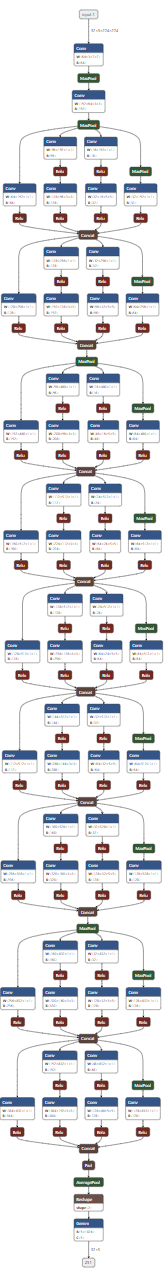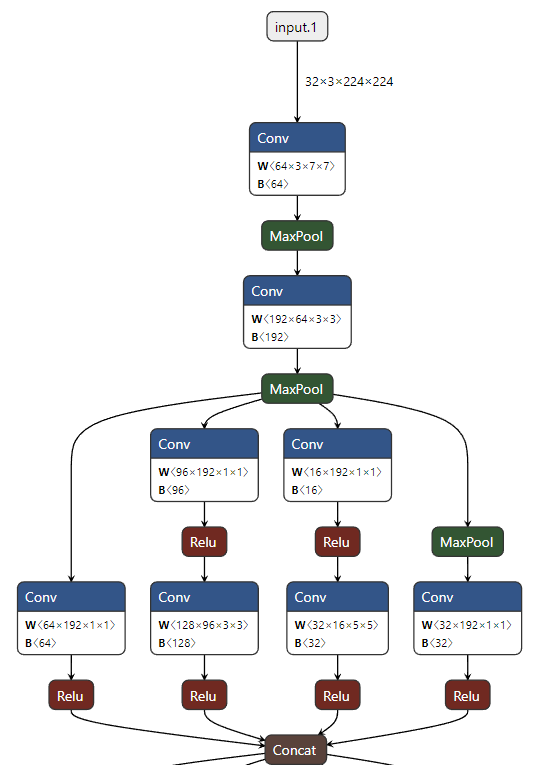

# 실습과제 : Flower Photos 학습   
1. Flower Photos dataset으로 학습하기
* model을 수정해서 생성하자
* Dataset을 준비하자
* Training 및 성능을 확인 하자
2. Pre-trained GoogLeNet모델과 성능을 비교해 보자
* 모델을 load하고
* 성능을 확인하자


### 실습 1: GoogleNet 적용

#### **Dataset Load**

##### ImageFolde(), DataLoader() 사용

In [11]:
from torchvision.datasets.utils import download_and_extract_archive

dataset_url = \
      "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
root = './'
data_dir='Dataset'
download_and_extract_archive(dataset_url, root, data_dir)
data_dir = root+data_dir+'/flower_photos'
data_dir

100%|██████████| 229M/229M [00:01<00:00, 134MB/s]


'./Dataset/flower_photos'

In [12]:
!ls {data_dir}

daisy  dandelion  LICENSE.txt  roses  sunflowers  tulips


In [13]:
#!rm -r 'flower_photos_sp'

##### Train / Test Data split

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders
import pathlib

sp_path="flower_photos_sp"
splitfolders.ratio(data_dir, output=sp_path,
    seed=1337, ratio=(.7, .3), group_prefix=None, move=True )
sp_train = pathlib.Path(sp_path+'/train')
sp_test = pathlib.Path(sp_path+'/val')
sp_train,sp_test

##### Check Images

In [ ]:
# 지정 폴더 아래에 있는 모든 *.jpg 파일의 수
#  및 폴더명 목록을 리턴
def check_dir(d_path):
    img_count = len(list(d_path.glob('*/*.jpg')))
    c_name = np.array([item.name for item in d_path.glob('*') if item.name != "LICENSE.txt"])
    return img_count, c_name, len(c_name)

# check_dir()로 폴더명과 이미지 숫자 확인
image_count, CLASS_train, class_num = check_dir(sp_train)
CLASS_train.sort()
print('Train image_count: {}\nclasses: {}'.format(image_count, CLASS_train))
image_count, CLASS_test, class_num = check_dir(sp_test)
CLASS_test.sort()
print('Test image_count: {}\nclasses: {}'.format(image_count, CLASS_test))

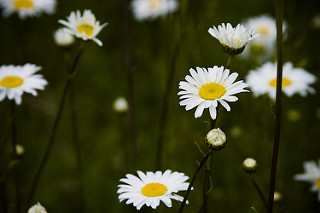

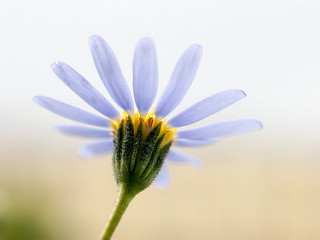

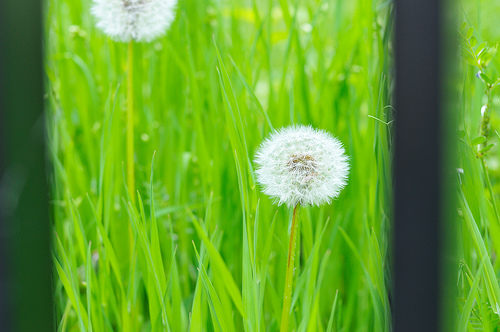

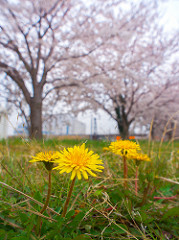

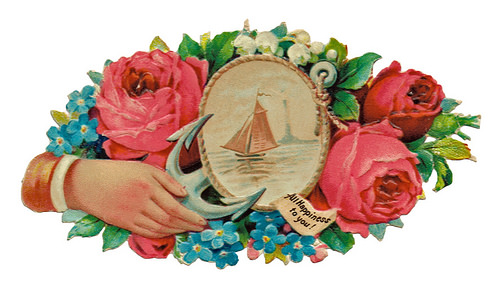

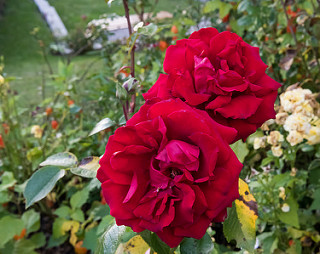

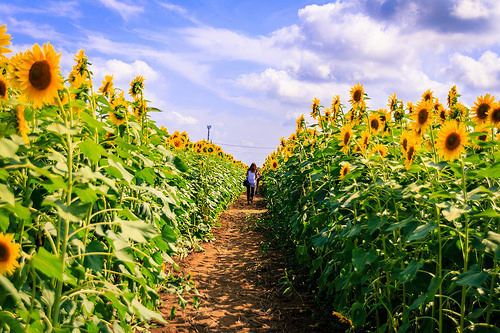

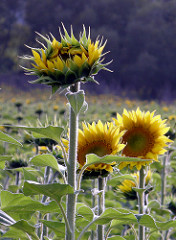

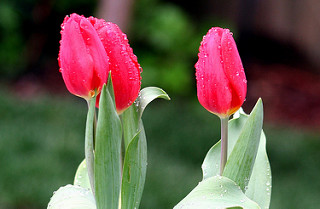

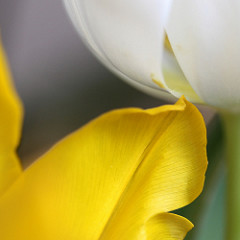

In [ ]:
from IPython import display
from PIL import Image

# 지정 path 아래에 있는 폴더에서 이미지 두장씩을 확인
def check_image(d_path, class_list):
    for i in range(len(class_list)):
        class_temp = list(d_path.glob(str(class_list[i])+'/*'))
        for image_path in class_temp[:2]:
            display.display(Image.open(str(image_path)))
# check_image()로 이미지 두장씩 확인
check_image(sp_train, CLASS_train)

#### ImageFolder, DataLoader 적용

In [ ]:
# Imagae size 결정 **
IMG_SIZE = 224
batch_size = 32 #64

In [ ]:
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

## loader에 적용할 transform
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    # v2.RandomAffine(degrees=40, translate=(0.2, 0.2), shear=0.2),
    # v2.RandomResizedCrop(IN_IMG_SIZE, scale=[0.8, 1.0]),
    # v2.RandomHorizontalFlip(0.5),
    v2.ToDtype(torch.float32, scale=True) ] )

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToDtype(torch.float32, scale=True) ] )

## ImageFolder : folder로 구성된 image set을 위한 loader
train_imgs = ImageFolder(sp_train, transform=train_transforms) #(image,label)
test_imgs = ImageFolder(sp_test, transform=test_transforms)

## DataLoader : dataset과 sampler를 결합 batch단위 제공 #(image,label)*batch
train_loader = DataLoader(train_imgs, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_imgs, batch_size=batch_size, shuffle=False, num_workers=4)

len(train_imgs),len(test_imgs)

(2567, 1103)

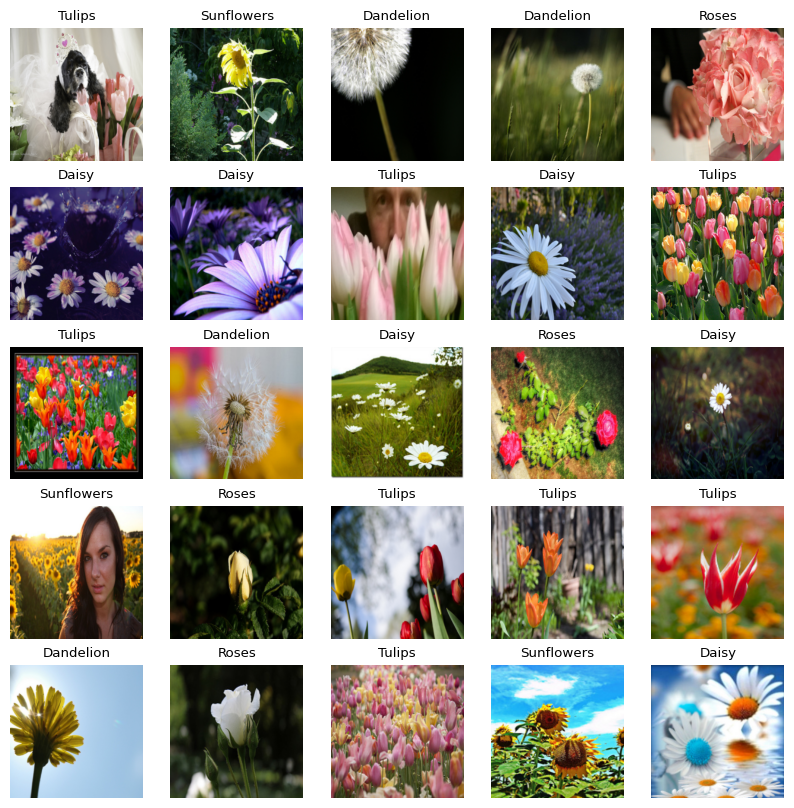

In [ ]:
def show_batch(data_gen, class_l):
    # get image and label from data generator
    img_batch, l_batch = next(iter(data_gen))
    plt.figure(figsize=(10,10))
    for n in range(25):
        ax = plt.subplot(5,5,n+1)
        plt.imshow(img_batch[n].permute(1, 2, 0))
        plt.title(class_l[l_batch[n]].title())
        plt.axis('off')
    return img_batch, l_batch

# check dataset
_,_ = show_batch(train_loader, CLASS_train)
#_,_ = show_batch(test_loader, CLASS_test)

#### Model Redefine & Training

In [ ]:
model = GoogLeNet(num_classes=5)
summary(model,input_size=(16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [16, 5]                   --
├─Sequential: 1-1                        [16, 192, 28, 28]         --
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        9,472
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        128
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                    [16, 64, 56, 56]          --
│    └─Conv2d: 2-5                       [16, 192, 56, 56]         110,784
│    └─BatchNorm2d: 2-6                  [16, 192, 56, 56]         384
│    └─ReLU: 2-7                         [16, 192, 56, 56]         --
│    └─MaxPool2d: 2-8                    [16, 192, 28, 28]         --
├─Sequential: 1-2                        [16, 480, 14, 14]         --
│    └─inception_module: 2-9             [16, 256, 28, 28]         --
│    │    └─Sequential: 3-1              [16, 64, 28, 28]          12,352
│

In [ ]:
%%time
model = GoogLeNet(num_classes=5)
model_name = "GoogLeNet-5"

epochs = 30
logger = CSVLogger("logs", name=model_name)
trainer = Trainer(max_epochs=epochs, logger=logger,
                  limit_train_batches=0.7, limit_val_batches=1.0)
trainer.fit(model, train_loader, test_loader)
# Wall time: 2min 58s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: `Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
INFO:lightning.pytorch.utilities.rank_zero:`Trainer(limit_val_batches=

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


CPU times: user 2min 1s, sys: 20.3 s, total: 2min 21s
Wall time: 2min 57s


#### Analysis

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{model_name}/version_{v_num}/metrics.csv')

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_1 = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = model_name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_1:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
#plt.semilogy()
plt.legend()
plt.grid()
plt.show()

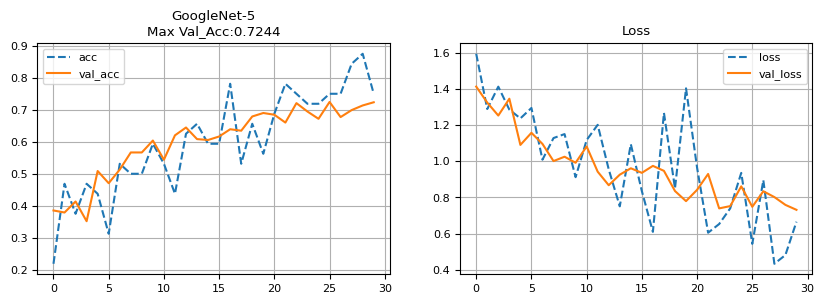

## 실습 2: CNN_BN 적용

### Model Define

In [ ]:
class CNN_BN(Wrap_5):
    def __init__(self):
        super(CNN_BN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Dropout(0.4), ##
            nn.Linear(512*7*7, 5)
            )

    def forward(self, x):
        out = self.layers(x)
        return out

model_BN = CNN_BN()
summary(model_BN, input_size=(16, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_BN                                   [16, 5]                   --
├─Sequential: 1-1                        [16, 5]                   --
│    └─Conv2d: 2-1                       [16, 128, 224, 224]       3,584
│    └─BatchNorm2d: 2-2                  [16, 128, 224, 224]       256
│    └─ReLU: 2-3                         [16, 128, 224, 224]       --
│    └─MaxPool2d: 2-4                    [16, 128, 112, 112]       --
│    └─Conv2d: 2-5                       [16, 128, 112, 112]       147,584
│    └─BatchNorm2d: 2-6                  [16, 128, 112, 112]       256
│    └─ReLU: 2-7                         [16, 128, 112, 112]       --
│    └─MaxPool2d: 2-8                    [16, 128, 56, 56]         --
│    └─Conv2d: 2-9                       [16, 256, 56, 56]         295,168
│    └─BatchNorm2d: 2-10                 [16, 256, 56, 56]         512
│    └─ReLU: 2-11                        [16, 256, 56, 56]         --

### Training

In [ ]:
%%time
model_BN = CNN_BN()
model_name = "CNN_BN"

epochs=15
logger = CSVLogger("logs", name=model_name)
trainer = Trainer(max_epochs=epochs, logger=logger,
                  limit_train_batches=0.7, limit_val_batches=1.0)
trainer.fit(model_BN, train_loader, test_loader)
# Wall time: 2min 58s

Wall time: 2min 58s

In [ ]:
model_BN_v_num = logger.version
history = pd.read_csv(f'./logs/{model_name}/version_{model_BN_v_num}/metrics.csv')

### *Plot*

In [ ]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_1 = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = model_name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_1:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
#plt.semilogy()
plt.legend()
plt.grid()
plt.show()

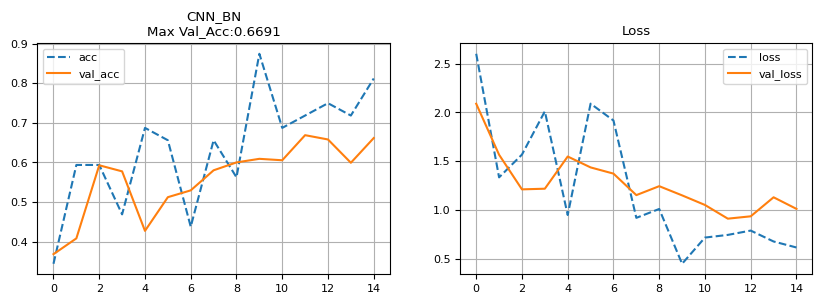

## 두 모델 비교 : Parameter, Operation,...

In [ ]:
model = GoogLeNet(num_classes=5)
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [1, 5]                    --
├─Sequential: 1-1                        [1, 192, 28, 28]          --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,472
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 192, 56, 56]          110,784
│    └─BatchNorm2d: 2-6                  [1, 192, 56, 56]          384
│    └─ReLU: 2-7                         [1, 192, 56, 56]          --
│    └─MaxPool2d: 2-8                    [1, 192, 28, 28]          --
├─Sequential: 1-2                        [1, 480, 14, 14]          --
│    └─inception_module: 2-9             [1, 256, 28, 28]          --
│    │    └─Sequential: 3-1              [1, 64, 28, 28]           12,352
│

In [ ]:
model_BN = CNN_BN()
summary(model_BN, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_BN                                   [1, 5]                    --
├─Sequential: 1-1                        [1, 5]                    --
│    └─Conv2d: 2-1                       [1, 128, 224, 224]        3,584
│    └─BatchNorm2d: 2-2                  [1, 128, 224, 224]        256
│    └─ReLU: 2-3                         [1, 128, 224, 224]        --
│    └─MaxPool2d: 2-4                    [1, 128, 112, 112]        --
│    └─Conv2d: 2-5                       [1, 128, 112, 112]        147,584
│    └─BatchNorm2d: 2-6                  [1, 128, 112, 112]        256
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-8                    [1, 128, 56, 56]          --
│    └─Conv2d: 2-9                       [1, 256, 56, 56]          295,168
│    └─BatchNorm2d: 2-10                 [1, 256, 56, 56]          512
│    └─ReLU: 2-11                        [1, 256, 56, 56]          --

## 실습 3: Pre-trained GoogleNet 적용  

**torchvision.models에서 가져오기**   
https://pytorch.org/vision/stable/models.html#classification

In [ ]:
import torchvision.models as models
model = models.googlenet(pretrained=True)
#inception = models.inception_v3(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 193MB/s]


**Github에서 가져오기**  
https://github.com/pytorch/vision  
https://pytorch.org/hub/pytorch_vision_googlenet/

In [ ]:
#torch.hub.list('pytorch/vision')

In [ ]:
#model = torch.hub.load('pytorch/vision', 'googlenet', pretrained=True)

#### Imagenet Class Label 읽어오기

In [ ]:
# Download ImageNet labels
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

--2025-10-29 00:43:52--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2025-10-29 00:43:52 (111 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



In [ ]:
# Read the categories
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

In [ ]:
p(categories[:5],)
p(categories[-5:])
len(categories)

[]:
Type: <class 'list'>
Values: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']
[]:
Type: <class 'list'>
Values: ['earthstar', 'hen-of-the-woods', 'bolete', 'ear', 'toilet tissue']


1000

Type: <class 'list'>
Values: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']
Type: <class 'list'>
Values: ['earthstar', 'hen-of-the-woods', 'bolete', 'ear', 'toilet tissue']
1000

#### Inference

In [ ]:
model.eval() ##
imgs, labels = next(iter(train_loader)) #(64,img),(64,label)
p(labels)
outputs = model(imgs) # (64,1000)

idx = F.softmax(outputs, dim=1)
# Show top categories per image
top5_prob, top5_catid = torch.topk(idx, 5) #(64,1),(64,1)
for i in range(top5_prob.size(0)): # 64
      print(f'{CLASS_test[labels[i]]:10s}:{categories[top5_catid[i,0]]:15s},{top5_prob[i,0]:0.4f}')


[]:
Shape:torch.Size([32])
Type: <class 'torch.Tensor'>
Values: tensor([1, 2, 4, 0, 1, 1, 2, 4, 0, 2, 0, 4, 1, 3, 1, 1, 4, 3, 1, 3, 2, 3, 2, 1,
        1, 0, 0, 4, 1, 3, 1, 2])
dandelion :sea urchin     ,0.0782
roses     :menu           ,0.2330
tulips    :picket fence   ,0.1602
daisy     :daisy          ,0.7015
dandelion :hip            ,0.0861
dandelion :jellyfish      ,0.1856
roses     :picket fence   ,0.9898
tulips    :picket fence   ,0.1941
daisy     :cabbage butterfly,0.0650
roses     :cauliflower    ,0.0900
daisy     :daisy          ,0.9858
tulips    :picket fence   ,0.1194
dandelion :sea urchin     ,0.3030
sunflowers:vase           ,0.1098
dandelion :safety pin     ,0.2064
dandelion :daisy          ,0.2991
tulips    :rapeseed       ,0.1900
sunflowers:daisy          ,0.3614
dandelion :daisy          ,0.1812
sunflowers:daisy          ,0.2479
roses     :coral fungus   ,0.0813
sunflowers:sea anemone    ,0.2644
roses     :greenhouse     ,0.1385
dandelion :volcano        ,0.2290
dande

In [ ]:
# categories와 CLASS_train 겹치는 경우
# categorie id와 name 확인
for i in range(len(categories)):
  if categories[i] in CLASS_train:
    print( i, categories[i])

985 daisy
